## Environment Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from math import radians, cos, sin, asin, sqrt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
# Load Dataset
df = pd.read_csv('dataset.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (10194, 18)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [4]:
# ── Factory & Product Mapping 
FACTORY_COORDS = {
    "Lot's O' Nuts":     {'lat': 32.881893, 'lon': -111.768036},
    "Wicked Choccy's":  {'lat': 32.076176, 'lon':  -81.088371},
    "Sugar Shack":      {'lat': 48.119140, 'lon':  -96.181150},
    "Secret Factory":   {'lat': 41.446333, 'lon':  -90.565487},
    "The Other Factory":{'lat': 35.117500, 'lon':  -89.971107},
}

PRODUCT_FACTORY = {
    'Wonka Bar - Nutty Crunch Surprise':  "Lot's O' Nuts",
    'Wonka Bar - Fudge Mallows':          "Lot's O' Nuts",
    'Wonka Bar -Scrumdiddlyumptious':     "Lot's O' Nuts",
    'Wonka Bar - Milk Chocolate':         "Wicked Choccy's",
    'Wonka Bar - Triple Dazzle Caramel':  "Wicked Choccy's",
    'Laffy Taffy':                        'Sugar Shack',
    'SweeTARTS':                          'Sugar Shack',
    'Nerds':                              'Sugar Shack',
    'Fun Dip':                            'Sugar Shack',
    'Fizzy Lifting Drinks':               'Sugar Shack',
    'Everlasting Gobstopper':             'Secret Factory',
    'Lickable Wallpaper':                 'Secret Factory',
    'Wonka Gum':                          'Secret Factory',
    'Hair Toffee':                        'The Other Factory',
    'Kazookles':                          'The Other Factory',
}

print(' Factory coordinates and product-factory mapping defined.')
pd.DataFrame(FACTORY_COORDS).T

 Factory coordinates and product-factory mapping defined.


,lat,lon
Lot's O' Nuts,32.881893,-111.768036
Wicked Choccy's,32.076176,-81.088371
Sugar Shack,48.119140,-96.181150
Secret Factory,41.446333,-90.565487
The Other Factory,35.117500,-89.971107


## Data Cleaning & Feature Engineering

In [5]:
# ── Parse Dates & Compute Lead Time 
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)
df['Lead_Time_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

print(f'Lead Time range: {df.Lead_Time_Days.min()} – {df.Lead_Time_Days.max()} days')
print(f'Missing values:\n{df.isnull().sum()[df.isnull().sum()>0]}')
df.describe()

Lead Time range: 904 – 1642 days
Missing values:
Series([], dtype: int64)


,Row ID,Order Date,Ship Date,Customer ID,Sales,Units,Gross Profit,Cost,Lead_Time_Days
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-03-13 03:08:26.415538176,2028-10-23 23:20:43.790465024,134468.961154,13.908537,3.791838,9.166451,4.742087,1320.841868
min,1.000000,2024-01-02 00:00:00,2026-06-30 00:00:00,100006.000000,1.250000,1.000000,0.250000,0.600000,904.000000
25%,2549.250000,2024-09-28 00:00:00,2027-11-09 00:00:00,117212.000000,7.200000,2.000000,4.900000,2.400000,1271.000000
50%,5097.500000,2025-04-06 12:00:00,2028-12-18 00:00:00,133550.000000,10.800000,3.000000,7.470000,3.600000,1274.000000
75%,7645.750000,2025-09-16 00:00:00,2029-11-08 00:00:00,152051.000000,18.000000,5.000000,12.250000,5.700000,1638.000000
max,10194.000000,2025-12-31 00:00:00,2030-06-28 00:00:00,192314.000000,260.000000,14.000000,130.000000,130.000000,1642.000000
std,2942.898656,NaN,NaN,20231.483007,11.341020,2.228317,6.643740,5.061647,262.444892


In [6]:
# ── Outlier Removal (IQR on Lead Time) 
Q1, Q3 = df['Lead_Time_Days'].quantile([0.25, 0.75])
IQR = Q3 - Q1
before = len(df)
df = df[(df['Lead_Time_Days'] >= Q1 - 3*IQR) & (df['Lead_Time_Days'] <= Q3 + 3*IQR)]
print(f'Rows removed as outliers: {before - len(df)} | Remaining: {len(df)}')

Rows removed as outliers: 0 | Remaining: 10194


In [7]:
# ── Add Factory, Coordinates & Haversine Distance 
def haversine(lat1, lon1, lat2, lon2):
    R = 3958.8  # miles
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return R * 2 * asin(sqrt(a))

# US city lat/lon lookup (using postal code centroid approximation via a small dict)
# For full accuracy, use geopy or a zip code database
REGION_CENTROIDS = {
    'Atlantic': (40.7128,  -74.0060),
    'Pacific':  (37.7749, -122.4194),
    'Interior': (41.8781,  -87.6298),
    'Gulf':     (29.7604,  -95.3698),
}

df['Factory'] = df['Product Name'].map(PRODUCT_FACTORY)
df['Factory_Lat'] = df['Factory'].map(lambda f: FACTORY_COORDS[f]['lat'] if f in FACTORY_COORDS else np.nan)
df['Factory_Lon'] = df['Factory'].map(lambda f: FACTORY_COORDS[f]['lon'] if f in FACTORY_COORDS else np.nan)

df['Region_Lat'] = df['Region'].map(lambda r: REGION_CENTROIDS.get(r, (39.5, -98.35))[0])
df['Region_Lon'] = df['Region'].map(lambda r: REGION_CENTROIDS.get(r, (39.5, -98.35))[1])

df['Distance_Miles'] = df.apply(
    lambda row: haversine(row.Factory_Lat, row.Factory_Lon, row.Region_Lat, row.Region_Lon), axis=1
)

# Profit margin
df['Profit_Margin'] = df['Gross Profit'] / df['Sales'].replace(0, np.nan)

print(' Feature engineering complete.')
df[['Product Name','Factory','Region','Distance_Miles','Lead_Time_Days','Profit_Margin']].head(10)

 Feature engineering complete.


,Product Name,Factory,Region,Distance_Miles,Lead_Time_Days,Profit_Margin
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Interior,766.899723,909,0.649231
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Interior,766.899723,909,0.653333
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Interior,1457.098608,909,0.713467
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Interior,1457.098608,909,0.694444
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Atlantic,714.432809,912,0.653333
5,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Gulf,990.517611,909,0.694444
6,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Gulf,860.844477,909,0.653333
7,Wonka Bar - Milk Chocolate,Wicked Choccy's,Gulf,860.844477,906,0.649231
8,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Gulf,990.517611,909,0.713467
9,Wonka Bar - Milk Chocolate,Wicked Choccy's,Gulf,860.844477,909,0.649231


In [7]:
# ── Encode Categoricals for Modeling 
le_ship  = LabelEncoder()
le_reg   = LabelEncoder()
le_fact  = LabelEncoder()
le_prod  = LabelEncoder()

df['Ship_Mode_Enc'] = le_ship.fit_transform(df['Ship Mode'])
df['Region_Enc']    = le_reg.fit_transform(df['Region'])
df['Factory_Enc']   = le_fact.fit_transform(df['Factory'].fillna('Unknown'))
df['Product_Enc']   = le_prod.fit_transform(df['Product Name'])

print('Encodings:')
print('Ship Mode  :', dict(zip(le_ship.classes_, le_ship.transform(le_ship.classes_))))
print('Region     :', dict(zip(le_reg.classes_,  le_reg.transform(le_reg.classes_))))
print('Factory    :', dict(zip(le_fact.classes_,  le_fact.transform(le_fact.classes_))))

Encodings:
Ship Mode  : {'First Class': np.int64(0), 'Same Day': np.int64(1), 'Second Class': np.int64(2), 'Standard Class': np.int64(3)}
Region     : {'Atlantic': np.int64(0), 'Gulf': np.int64(1), 'Interior': np.int64(2), 'Pacific': np.int64(3)}
Factory    : {"Lot's O' Nuts": np.int64(0), 'Secret Factory': np.int64(1), 'Sugar Shack': np.int64(2), 'The Other Factory': np.int64(3), "Wicked Choccy's": np.int64(4)}


## Exploratory Data Analysis (EDA)

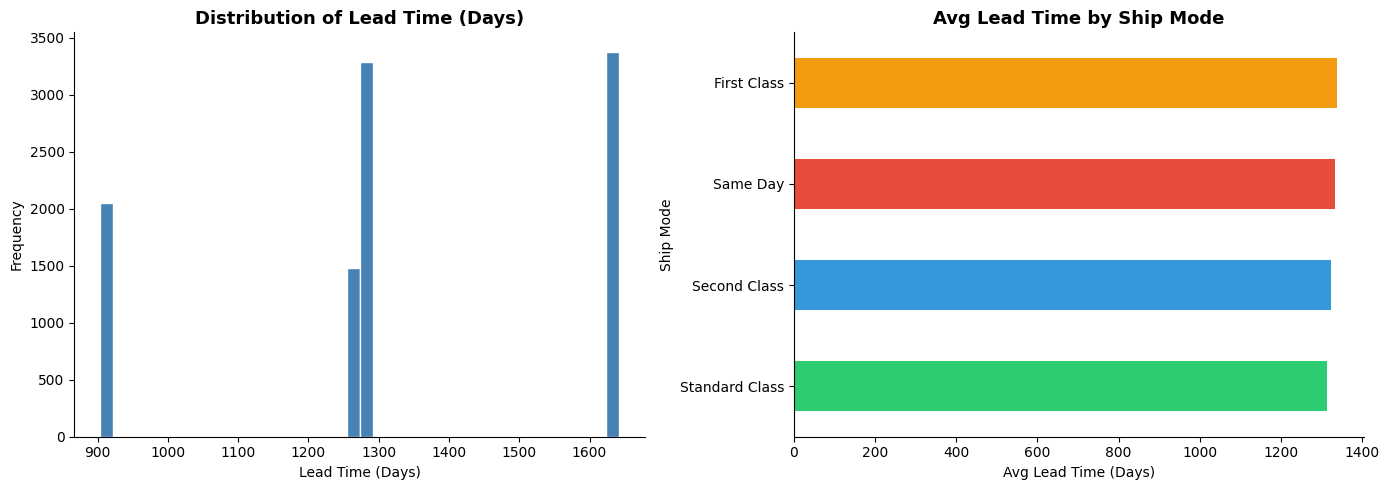

In [8]:
# ── Lead Time Distribution 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Lead_Time_Days'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Lead Time (Days)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Lead Time (Days)')
axes[0].set_ylabel('Frequency')

avg_lead = df.groupby('Ship Mode')['Lead_Time_Days'].mean().sort_values()
avg_lead.plot(kind='barh', ax=axes[1], color=['#2ecc71','#3498db','#e74c3c','#f39c12'])
axes[1].set_title('Avg Lead Time by Ship Mode', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg Lead Time (Days)')

plt.tight_layout()
plt.show()

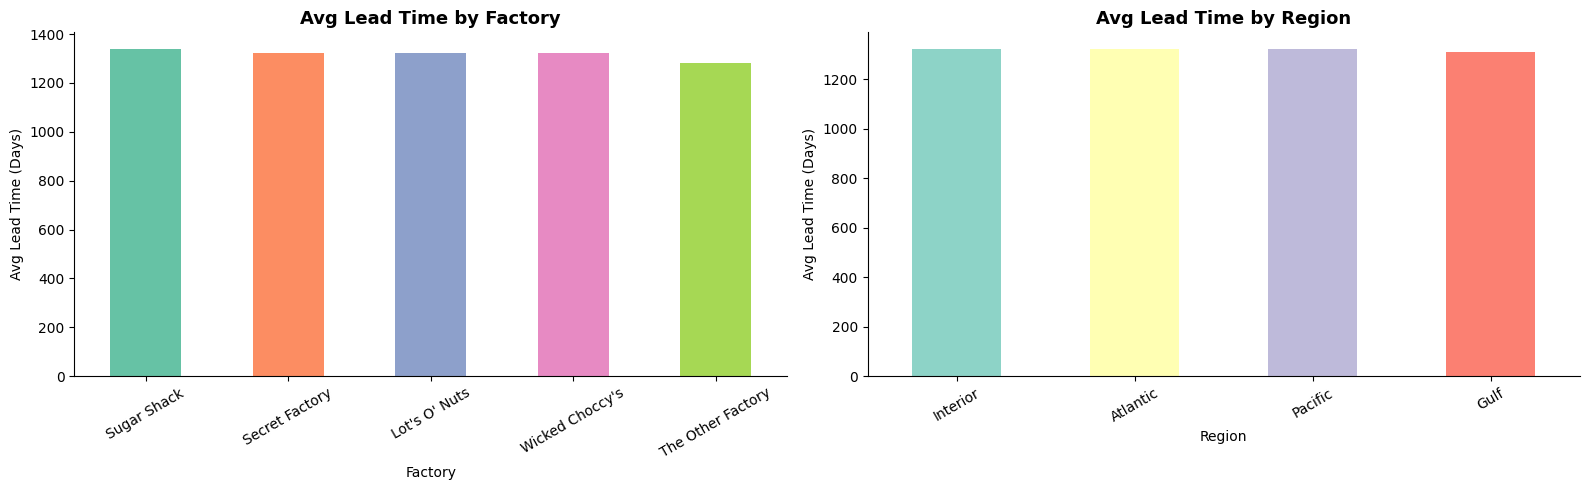

In [9]:
# ── Lead Time by Factory & Region 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

factory_lead = df.groupby('Factory')['Lead_Time_Days'].mean().sort_values(ascending=False)
factory_lead.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', len(factory_lead)))
axes[0].set_title('Avg Lead Time by Factory', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Factory')
axes[0].set_ylabel('Avg Lead Time (Days)')
axes[0].tick_params(axis='x', rotation=30)

region_lead = df.groupby('Region')['Lead_Time_Days'].mean().sort_values(ascending=False)
region_lead.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set3', len(region_lead)))
axes[1].set_title('Avg Lead Time by Region', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Avg Lead Time (Days)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

           Total_Sales  Total_Profit  Avg_Margin
Division                                        
Chocolate    131692.90      88824.62        0.67
Other          9663.25       4333.45        0.38
Sugar           427.48        284.73        0.58


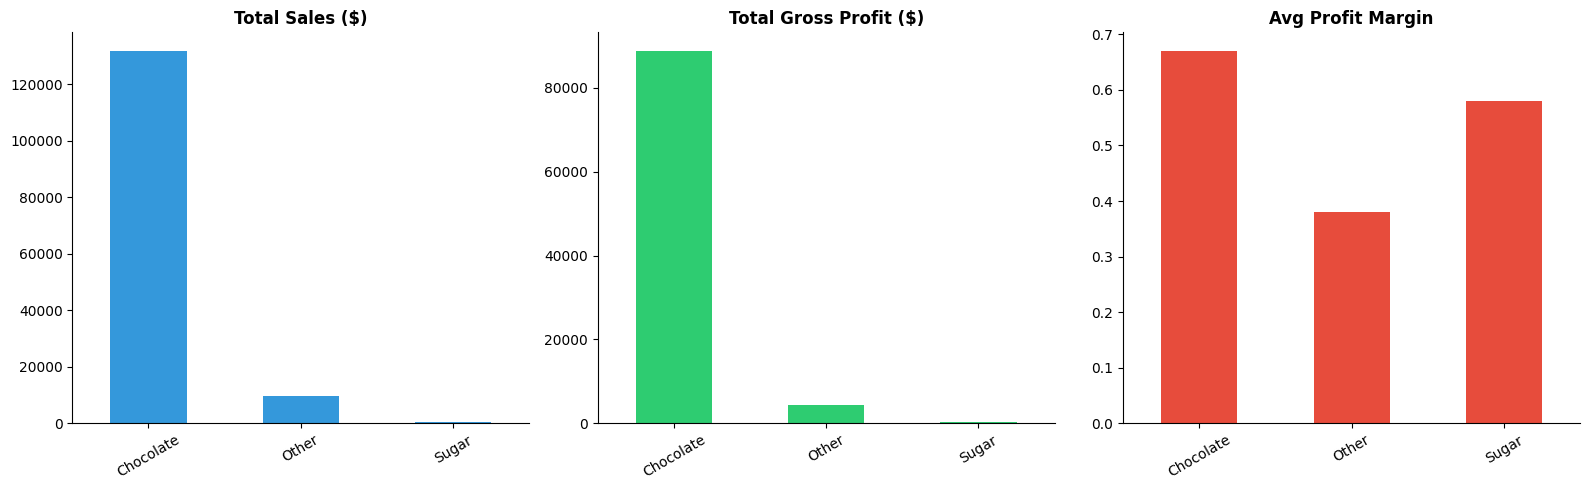

In [10]:
# ── Sales, Gross Profit & Margin by Division 
div_stats = df.groupby('Division').agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Gross Profit','sum'),
    Avg_Margin=('Profit_Margin','mean')
).round(2)

print(div_stats)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title, color in zip(axes,
    ['Total_Sales','Total_Profit','Avg_Margin'],
    ['Total Sales ($)', 'Total Gross Profit ($)', 'Avg Profit Margin'],
    ['#3498db','#2ecc71','#e74c3c']):
    div_stats[col].plot(kind='bar', ax=ax, color=color)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

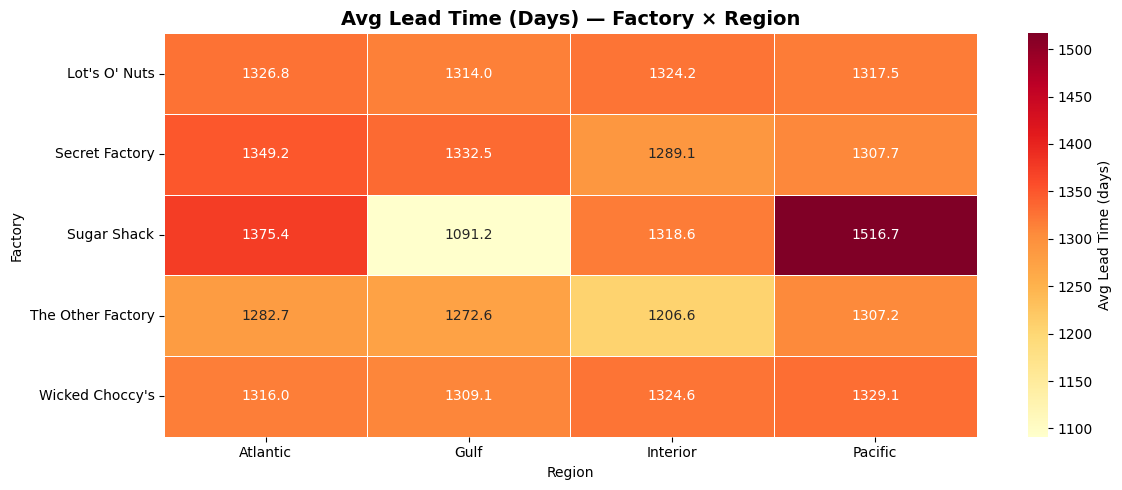

In [11]:
# ── Heatmap: Avg Lead Time — Factory × Region 
pivot = df.pivot_table(values='Lead_Time_Days', index='Factory', columns='Region', aggfunc='mean')

plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Avg Lead Time (days)'})
plt.title('Avg Lead Time (Days) — Factory × Region', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

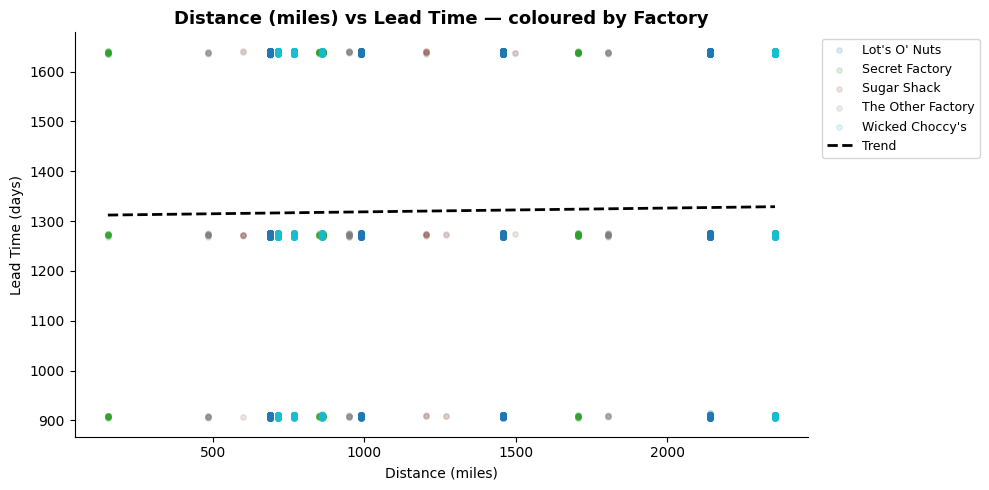

In [12]:
# ── Distance vs Lead Time Scatter 
plt.figure(figsize=(10, 5))
colors = plt.cm.tab10(np.linspace(0, 1, df['Factory'].nunique()))
for i, (factory, grp) in enumerate(df.groupby('Factory')):
    plt.scatter(grp['Distance_Miles'], grp['Lead_Time_Days'],
                alpha=0.15, s=15, color=colors[i], label=factory)

# trend line
m, b = np.polyfit(df['Distance_Miles'], df['Lead_Time_Days'], 1)
xs = np.linspace(df['Distance_Miles'].min(), df['Distance_Miles'].max(), 200)
plt.plot(xs, m*xs + b, 'k--', linewidth=2, label='Trend')

plt.title('Distance (miles) vs Lead Time — coloured by Factory', fontsize=13, fontweight='bold')
plt.xlabel('Distance (miles)')
plt.ylabel('Lead Time (days)')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

                                   Total_Units  Avg_Lead_Time  Avg_Margin
Product Name                                                             
Wonka Bar - Milk Chocolate                8267       1316.765       0.649
Wonka Bar -Scrumdiddlyumptious            7743       1320.642       0.694
Wonka Bar - Triple Dazzle Caramel         7596       1325.661       0.653
Wonka Bar - Fudge Mallows                 6914       1314.242       0.667
Wonka Bar - Nutty Crunch Surprise         6755       1328.915       0.713
Wonka Gum                                  478       1306.525       0.520
Lickable Wallpaper                         393       1339.138       0.500
Kazookles                                  371       1272.990       0.077
SweeTARTS                                   41       1383.500       0.467
Laffy Taffy                                 27       1383.100       0.623


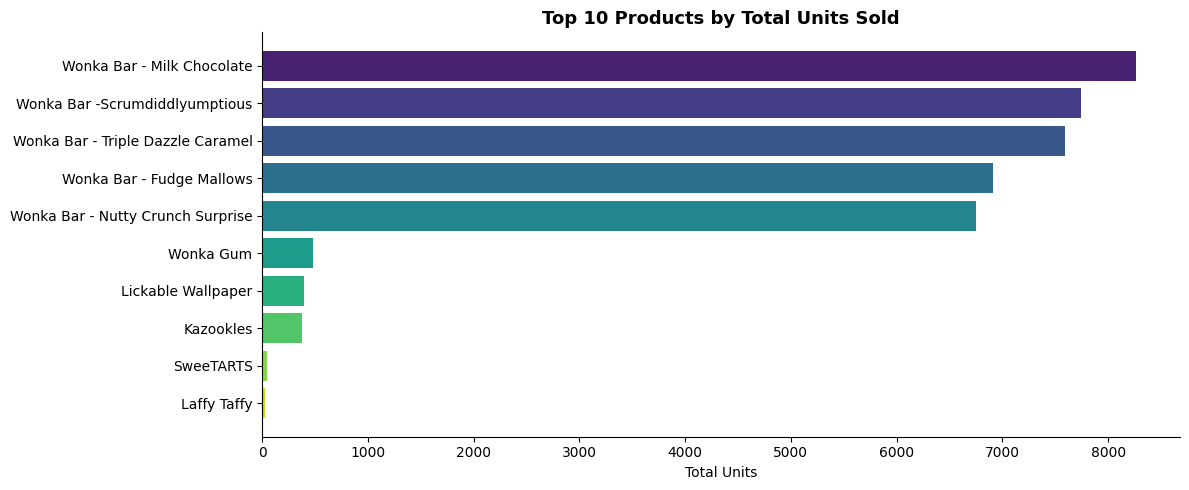

In [13]:
# ── Top 10 Products by Volume & Margin 
prod_stats = df.groupby('Product Name').agg(
    Total_Units=('Units','sum'),
    Avg_Lead_Time=('Lead_Time_Days','mean'),
    Avg_Margin=('Profit_Margin','mean')
).sort_values('Total_Units', ascending=False).head(10)

print(prod_stats.round(3))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(prod_stats.index, prod_stats['Total_Units'],
               color=sns.color_palette('viridis', len(prod_stats)))
ax.set_title('Top 10 Products by Total Units Sold', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Units')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Route & Factory Clustering

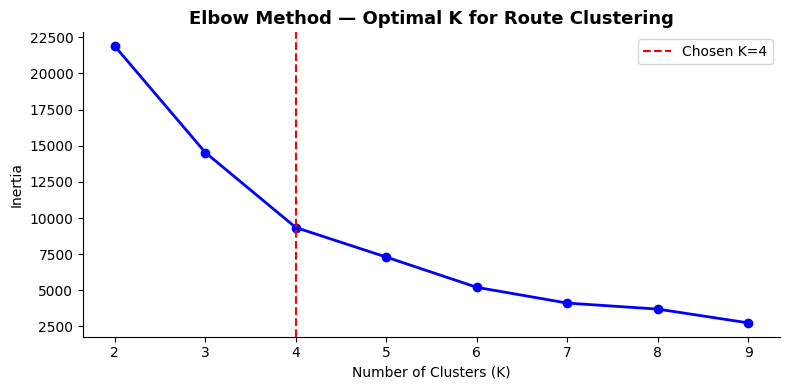

In [14]:
# ── K-Means on Route Performance 
cluster_features = ['Distance_Miles', 'Lead_Time_Days', 'Profit_Margin']
cluster_df = df[cluster_features].dropna()

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df)

# Elbow method
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2)
plt.axvline(x=4, color='red', linestyle='--', label='Chosen K=4')
plt.title('Elbow Method — Optimal K for Route Clustering', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.legend()
plt.tight_layout()
plt.show()

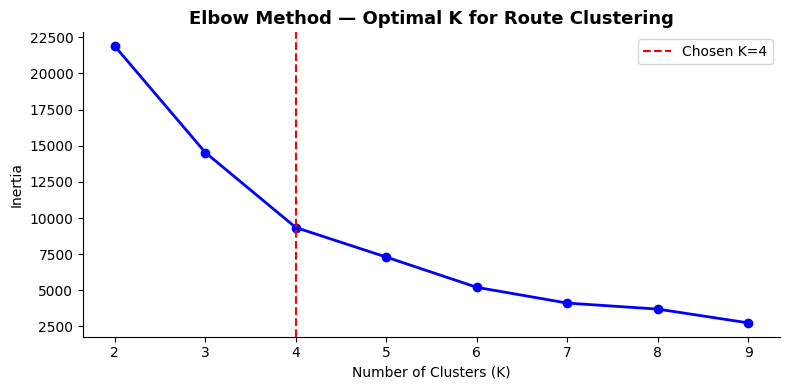

In [15]:
# ── K-Means on Route Performance 
cluster_features = ['Distance_Miles', 'Lead_Time_Days', 'Profit_Margin']
cluster_df = df[cluster_features].dropna()

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df)

# Elbow method
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2)
plt.axvline(x=4, color='red', linestyle='--', label='Chosen K=4')
plt.title('Elbow Method — Optimal K for Route Clustering', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# ── Identify Slow/Congested Routes 
slow_threshold = df['Lead_Time_Days'].quantile(0.80)
slow_routes = df[df['Lead_Time_Days'] > slow_threshold]

slow_combo = slow_routes.groupby(['Factory', 'Region']).agg(
    Count=('Lead_Time_Days','count'),
    Avg_Lead_Time=('Lead_Time_Days','mean'),
    Avg_Profit_Margin=('Profit_Margin','mean')
).sort_values('Avg_Lead_Time', ascending=False).head(10)

print(f'\n Top 10 Slow/Congested Factory–Region Combinations (>80th pct = {slow_threshold:.0f} days):')
print(slow_combo.round(2))


 Top 10 Slow/Congested Factory–Region Combinations (>80th pct = 1639 days):
                          Count  Avg_Lead_Time  Avg_Profit_Margin
Factory         Region                                           
Wicked Choccy's Pacific     172        1640.73               0.65
Lot's O' Nuts   Atlantic    204        1640.66               0.69
Wicked Choccy's Atlantic    135        1640.65               0.65
Lot's O' Nuts   Gulf        110        1640.65               0.69
Wicked Choccy's Interior    134        1640.63               0.65
Sugar Shack     Atlantic      5        1640.60               0.53
Secret Factory  Interior      5        1640.60               0.57
Lot's O' Nuts   Interior    167        1640.59               0.69
                Pacific     213        1640.59               0.69
Wicked Choccy's Gulf         77        1640.58               0.65


## Predictive Modeling — Lead Time

In [17]:
# ── Feature Matrix & Target 
FEATURES = ['Product_Enc', 'Factory_Enc', 'Region_Enc', 'Ship_Mode_Enc',
            'Distance_Miles', 'Units', 'Cost', 'Profit_Margin']
TARGET   = 'Lead_Time_Days'

model_df = df[FEATURES + [TARGET]].dropna()
X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_m = StandardScaler()
X_train_s = scaler_m.fit_transform(X_train)
X_test_s  = scaler_m.transform(X_test)

print(f'Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')

Train size: 8,155 | Test size: 2,039


In [18]:
# ── Train Three Models 
models = {
    'Linear Regression':       LinearRegression(),
    'Random Forest':           RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1),
    'Gradient Boosting':       GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, random_state=42),
}

results = {}
for name, mdl in models.items():
    mdl.fit(X_train_s, y_train)
    preds = mdl.predict(X_test_s)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    results[name] = {'RMSE': round(rmse,2), 'MAE': round(mae,2), 'R²': round(r2,4)}
    print(f'{name:25s}  RMSE={rmse:.2f}  MAE={mae:.2f}  R²={r2:.4f}')

results_df = pd.DataFrame(results).T.sort_values('R²', ascending=False)
best_model_name = results_df.index[0]
best_model = models[best_model_name]
print(f'\n Best Model: {best_model_name}')

Linear Regression          RMSE=266.02  MAE=214.85  R²=-0.0007
Random Forest              RMSE=277.03  MAE=224.84  R²=-0.0852
Gradient Boosting          RMSE=268.18  MAE=216.06  R²=-0.0170

 Best Model: Linear Regression


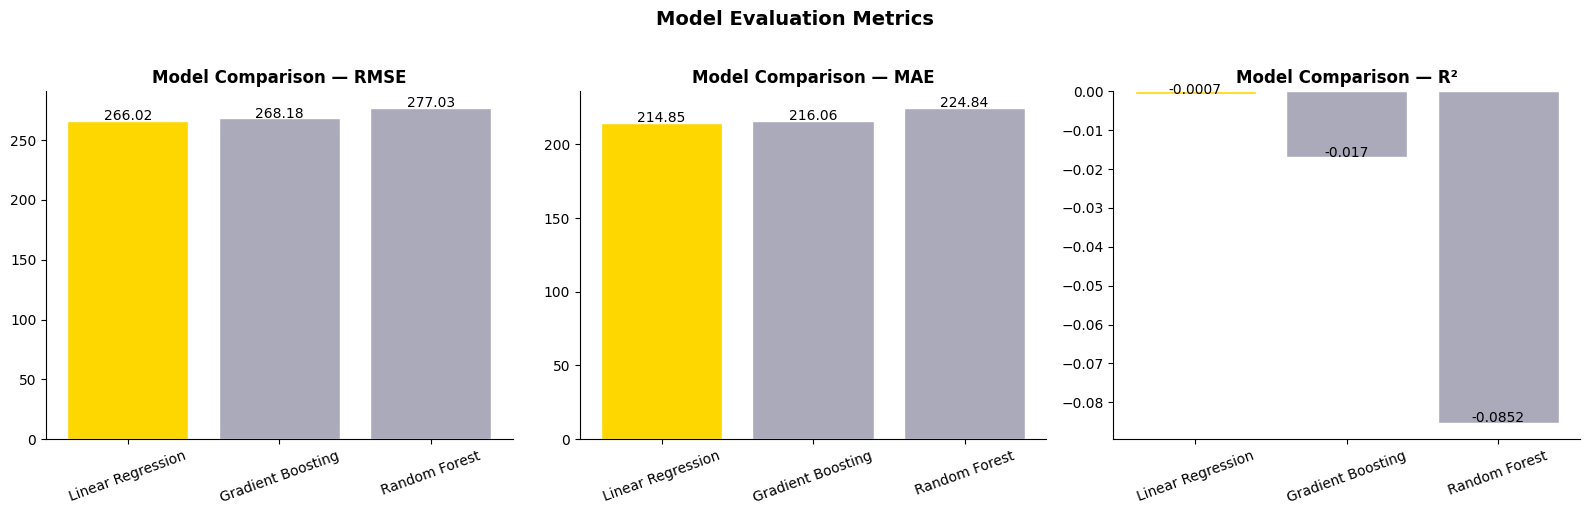

In [19]:
# ── Model Comparison Bar Chart 
metrics = ['RMSE', 'MAE', 'R²']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, metrics):
    vals = results_df[metric]
    colors = ['gold' if i==0 else '#aab' for i in range(len(vals))]
    ax.bar(vals.index, vals.values, color=colors, edgecolor='white')
    ax.set_title(f'Model Comparison — {metric}', fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    for j, v in enumerate(vals.values):
        ax.text(j, v + 0.002*abs(v), str(v), ha='center', fontsize=10)

plt.suptitle('Model Evaluation Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# ── Feature Importance (Best Tree-Based Model) 
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    plt.figure(figsize=(10, 5))
    fi.plot(kind='barh', color='steelblue')
    plt.title(f'Feature Importances — {best_model_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print('Feature importance not available for Linear Regression.')

Feature importance not available for Linear Regression.


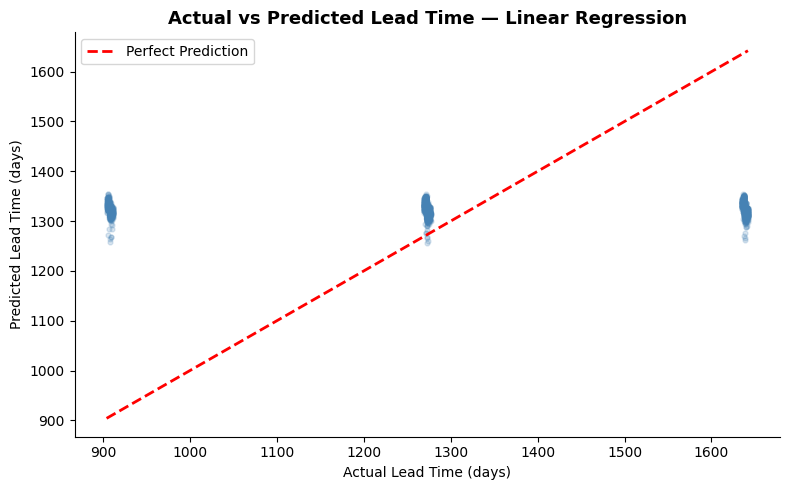

In [21]:
# ── Predicted vs Actual 
preds_best = best_model.predict(X_test_s)

plt.figure(figsize=(8, 5))
plt.scatter(y_test, preds_best, alpha=0.2, s=12, color='steelblue')
mn = min(y_test.min(), preds_best.min())
mx = max(y_test.max(), preds_best.max())
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')
plt.title(f'Actual vs Predicted Lead Time — {best_model_name}', fontsize=13, fontweight='bold')
plt.xlabel('Actual Lead Time (days)')
plt.ylabel('Predicted Lead Time (days)')
plt.legend()
plt.tight_layout()
plt.show()

## Scenario Simulation Engine

In [22]:
# ── Helper: predict lead time for a (product, factory, region, ship_mode) tuple
ALL_FACTORIES = list(FACTORY_COORDS.keys())

def predict_lead_time(product, factory, region, ship_mode, units=5, cost=5.0, margin=0.65):
    """Predict lead time using the best trained model."""
    try:
        prod_enc   = le_prod.transform([product])[0]
        fact_enc   = le_fact.transform([factory])[0]
        reg_enc    = le_reg.transform([region])[0]
        ship_enc   = le_ship.transform([ship_mode])[0]
    except ValueError:
        return None

    f_lat = FACTORY_COORDS[factory]['lat']
    f_lon = FACTORY_COORDS[factory]['lon']
    r_lat, r_lon = REGION_CENTROIDS.get(region, (39.5, -98.35))
    dist = haversine(f_lat, f_lon, r_lat, r_lon)

    row = np.array([[prod_enc, fact_enc, reg_enc, ship_enc, dist, units, cost, margin]])
    row_s = scaler_m.transform(row)
    return best_model.predict(row_s)[0]

# Quick sanity check
sample_lt = predict_lead_time('Wonka Bar - Milk Chocolate', "Wicked Choccy's", 'Pacific', 'Standard Class')
print(f'Sample prediction: Milk Chocolate → Pacific (Standard Class) = {sample_lt:.1f} days')

Sample prediction: Milk Chocolate → Pacific (Standard Class) = 1315.8 days


In [23]:
# ── Simulate ALL factory alternatives for EVERY product × region × ship_mode ──
REGIONS    = df['Region'].unique().tolist()
SHIP_MODES = df['Ship Mode'].unique().tolist()

simulation_rows = []
for product, current_factory in PRODUCT_FACTORY.items():
    if product not in le_prod.classes_:
        continue
    for region in REGIONS:
        if region not in le_reg.classes_:
            continue
        for ship in SHIP_MODES:
            if ship not in le_ship.classes_:
                continue
            current_lt = predict_lead_time(product, current_factory, region, ship)
            if current_lt is None:
                continue
            for alt_factory in ALL_FACTORIES:
                if alt_factory == current_factory:
                    continue
                if alt_factory not in le_fact.classes_:
                    continue
                alt_lt = predict_lead_time(product, alt_factory, region, ship)
                if alt_lt is None:
                    continue
                simulation_rows.append({
                    'Product':          product,
                    'Current_Factory':  current_factory,
                    'Alt_Factory':      alt_factory,
                    'Region':           region,
                    'Ship_Mode':        ship,
                    'Current_LT':       round(current_lt, 1),
                    'Alt_LT':           round(alt_lt, 1),
                    'LT_Delta':         round(current_lt - alt_lt, 1),
                    'LT_Pct_Reduction': round((current_lt - alt_lt) / max(current_lt, 1) * 100, 1)
                })

sim_df = pd.DataFrame(simulation_rows)
print(f'Simulation rows: {len(sim_df):,}')
sim_df.head()

Simulation rows: 960


,Product,Current_Factory,Alt_Factory,Region,Ship_Mode,Current_LT,Alt_LT,LT_Delta,LT_Pct_Reduction
0,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,Interior,Standard Class,1312.1,1307.7,4.4,0.3
1,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Sugar Shack,Interior,Standard Class,1312.1,1307.0,5.1,0.4
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Secret Factory,Interior,Standard Class,1312.1,1304.6,7.5,0.6
3,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,The Other Factory,Interior,Standard Class,1312.1,1306.2,5.9,0.4
4,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,Interior,First Class,1335.9,1331.5,4.4,0.3


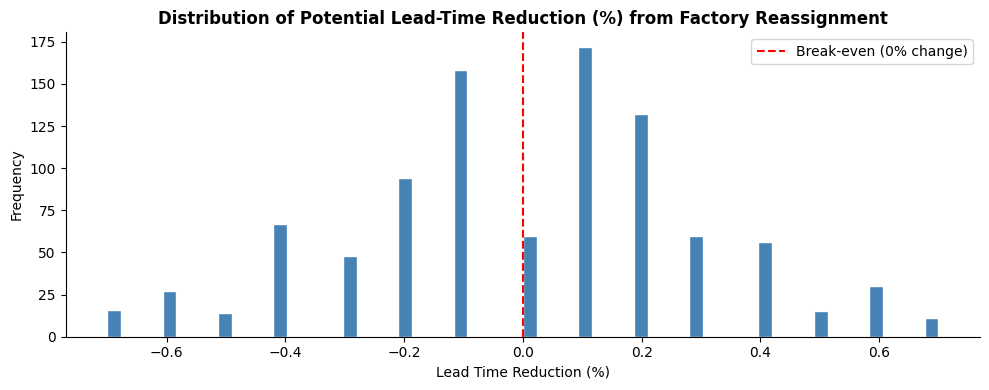

In [24]:
# ── Distribution of potential lead-time improvements ──────────────────────────
plt.figure(figsize=(10, 4))
plt.hist(sim_df['LT_Pct_Reduction'], bins=60, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', label='Break-even (0% change)')
plt.title('Distribution of Potential Lead-Time Reduction (%) from Factory Reassignment',
          fontsize=12, fontweight='bold')
plt.xlabel('Lead Time Reduction (%)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

## Optimization & Factory Reassignment Recommendations

In [25]:
# ── Aggregate: best alternative per (Product × Region × Ship Mode) 
best_alts = (
    sim_df[sim_df['LT_Delta'] > 0]          # only improvements
    .sort_values('LT_Delta', ascending=False)
    .drop_duplicates(subset=['Product','Region','Ship_Mode'])
)

print(f'Actionable reassignments (positive improvement): {len(best_alts):,}')
best_alts.head(10)

Actionable reassignments (positive improvement): 200


,Product,Current_Factory,Alt_Factory,Region,Ship_Mode,Current_LT,Alt_LT,LT_Delta,LT_Pct_Reduction
252,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,Pacific,Same Day,1331.7,1322.9,8.9,0.7
304,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,Pacific,Standard Class,1316.7,1307.8,8.9,0.7
244,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,Pacific,First Class,1339.7,1330.8,8.9,0.7
248,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,Pacific,Second Class,1323.8,1314.9,8.9,0.7
316,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,Pacific,Same Day,1332.5,1323.7,8.9,0.7
308,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,Pacific,First Class,1340.5,1331.6,8.9,0.7
312,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,Pacific,Second Class,1324.6,1315.7,8.9,0.7
240,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,Pacific,Standard Class,1315.8,1307.0,8.9,0.7
28,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,Atlantic,Same Day,1332.5,1324.0,8.6,0.6
24,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,Atlantic,Second Class,1324.6,1316.0,8.6,0.6


In [26]:
# ── Global Top-20 Recommendations 
top20 = best_alts.nlargest(20, 'LT_Delta')[[
    'Product','Current_Factory','Alt_Factory','Region','Ship_Mode',
    'Current_LT','Alt_LT','LT_Delta','LT_Pct_Reduction'
]].reset_index(drop=True)
top20.index += 1

print(' Top-20 Factory Reassignment Recommendations (by Lead-Time Savings):')
print(top20.to_string())

 Top-20 Factory Reassignment Recommendations (by Lead-Time Savings):
                              Product  Current_Factory      Alt_Factory    Region       Ship_Mode  Current_LT  Alt_LT  LT_Delta  LT_Pct_Reduction
1          Wonka Bar - Milk Chocolate  Wicked Choccy's    Lot's O' Nuts   Pacific        Same Day      1331.7  1322.9       8.9               0.7
2   Wonka Bar - Triple Dazzle Caramel  Wicked Choccy's    Lot's O' Nuts   Pacific  Standard Class      1316.7  1307.8       8.9               0.7
3          Wonka Bar - Milk Chocolate  Wicked Choccy's    Lot's O' Nuts   Pacific     First Class      1339.7  1330.8       8.9               0.7
4          Wonka Bar - Milk Chocolate  Wicked Choccy's    Lot's O' Nuts   Pacific    Second Class      1323.8  1314.9       8.9               0.7
5   Wonka Bar - Triple Dazzle Caramel  Wicked Choccy's    Lot's O' Nuts   Pacific        Same Day      1332.5  1323.7       8.9               0.7
6   Wonka Bar - Triple Dazzle Caramel  Wicked Choccy's 

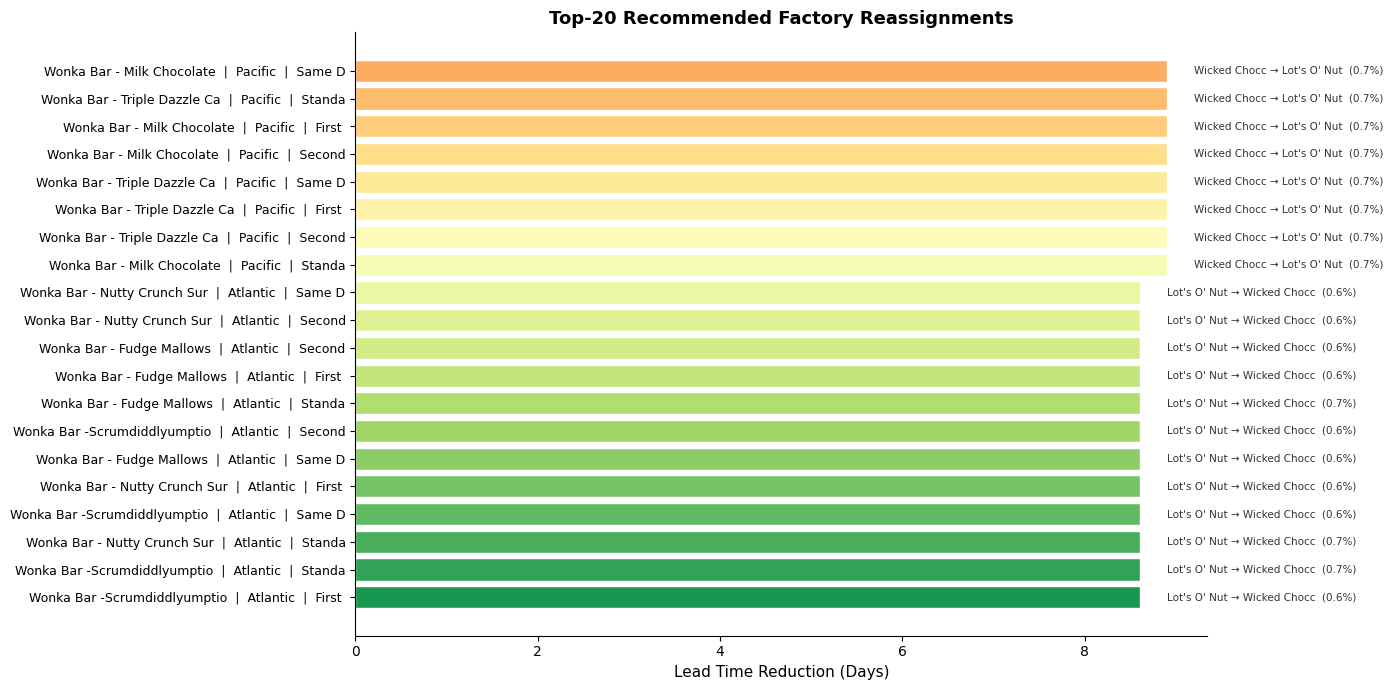

In [27]:
# ── Visualise Top-20 Recommendations 
fig, ax = plt.subplots(figsize=(14, 7))
y_pos = range(len(top20))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top20)))

bars = ax.barh(y_pos, top20['LT_Delta'].values, color=colors, edgecolor='white')
ax.set_yticks(list(y_pos))
labels = [f"{r['Product'][:28]}  |  {r['Region']}  |  {r['Ship_Mode'][:6]}" 
          for _, r in top20.iterrows()]
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Lead Time Reduction (Days)', fontsize=11)
ax.set_title('Top-20 Recommended Factory Reassignments', fontsize=13, fontweight='bold')

for bar, (_, row) in zip(bars, top20.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{row['Current_Factory'][:12]} → {row['Alt_Factory'][:12]}  ({row['LT_Pct_Reduction']}%)",
            va='center', fontsize=7.5, color='#333')

plt.tight_layout()
plt.show()

In [28]:
# ── Per-Product Recommendation Summary 
product_summary = (
    best_alts.groupby(['Product','Current_Factory'])
    .agg(
        Best_Alt_Factory=('Alt_Factory', lambda x: x.value_counts().idxmax()),
        Avg_LT_Reduction=('LT_Delta','mean'),
        Max_LT_Reduction=('LT_Delta','max'),
        Avg_Pct_Reduction=('LT_Pct_Reduction','mean'),
        Improvement_Scenarios=('LT_Delta','count')
    )
    .sort_values('Avg_LT_Reduction', ascending=False)
    .round(2)
    .reset_index()
)

print(' Per-Product Factory Reassignment Summary:')
print(product_summary.to_string(index=False))

 Per-Product Factory Reassignment Summary:
                          Product   Current_Factory  Best_Alt_Factory  Avg_LT_Reduction  Max_LT_Reduction  Avg_Pct_Reduction  Improvement_Scenarios
   Wonka Bar -Scrumdiddlyumptious     Lot's O' Nuts   Wicked Choccy's              6.43               8.6               0.48                     12
Wonka Bar - Nutty Crunch Surprise     Lot's O' Nuts   Wicked Choccy's              6.43               8.6               0.48                     12
        Wonka Bar - Fudge Mallows     Lot's O' Nuts   Wicked Choccy's              6.43               8.6               0.48                     12
       Wonka Bar - Milk Chocolate   Wicked Choccy's     Lot's O' Nuts              4.67               8.9               0.35                     12
Wonka Bar - Triple Dazzle Caramel   Wicked Choccy's     Lot's O' Nuts              4.67               8.9               0.35                     12
                          Fun Dip       Sugar Shack The Other Factory

In [37]:
# ── Profit Impact Analysis 
# Estimate: faster shipping → lower holding / logistics cost → better margin
# We use a conservative proxy: 0.1% margin gain per day saved
MARGIN_GAIN_PER_DAY = 0.001

product_volume = df.groupby('Product Name').agg(
    Avg_Sales=('Sales','mean'),
    Total_Sales=('Sales','sum')
).reset_index()

product_summary = product_summary.merge(
    product_volume.rename(columns={'Product Name':'Product'}), on='Product', how='left'
)
product_summary['Estimated_Annual_Profit_Uplift'] = (
    product_summary['Avg_LT_Reduction'] *
    MARGIN_GAIN_PER_DAY *
    product_summary['Total_Sales']
).round(2)

print('\n Estimated Annual Profit Uplift from Reassignment:')
print(product_summary[['Product','Current_Factory','Best_Alt_Factory',
                        'Avg_LT_Reduction','Estimated_Annual_Profit_Uplift']]
      .sort_values('Estimated_Annual_Profit_Uplift', ascending=False)
      .to_string(index=False))


 Estimated Annual Profit Uplift from Reassignment:
                          Product   Current_Factory  Best_Alt_Factory  Avg_LT_Reduction  Estimated_Annual_Profit_Uplift
   Wonka Bar -Scrumdiddlyumptious     Lot's O' Nuts   Wicked Choccy's              6.43                          179.23
        Wonka Bar - Fudge Mallows     Lot's O' Nuts   Wicked Choccy's              6.43                          160.05
Wonka Bar - Nutty Crunch Surprise     Lot's O' Nuts   Wicked Choccy's              6.43                          151.59
Wonka Bar - Triple Dazzle Caramel   Wicked Choccy's     Lot's O' Nuts              4.67                          133.02
       Wonka Bar - Milk Chocolate   Wicked Choccy's     Lot's O' Nuts              4.67                          125.47
               Lickable Wallpaper    Secret Factory     Lot's O' Nuts              3.03                           23.82
                        Kazookles The Other Factory     Lot's O' Nuts              3.00                     

In [35]:
# ── Risk Panel: High-Risk Reassignments 
# High-risk = reassignment saves time but alt factory has very low observed margin
factory_margin = df.groupby('Factory')['Profit_Margin'].mean()
MARGIN_RISK_THRESHOLD = factory_margin.mean() - factory_margin.std()

risky = best_alts.copy()
risky['Alt_Factory_Avg_Margin'] = risky['Alt_Factory'].map(factory_margin)
high_risk = risky[risky['Alt_Factory_Avg_Margin'] < MARGIN_RISK_THRESHOLD]

print(f' High-Risk Reassignments (alt factory below margin threshold {MARGIN_RISK_THRESHOLD:.3f}): {len(high_risk)}')
if len(high_risk):
    print(high_risk[['Product','Current_Factory','Alt_Factory',
                      'Region','LT_Delta','Alt_Factory_Avg_Margin']]
          .head(10).to_string(index=False))
else:
    print('No high-risk reassignments detected. All alternatives maintain acceptable margins.')

 High-Risk Reassignments (alt factory below margin threshold 0.266): 52
             Product Current_Factory       Alt_Factory Region  LT_Delta  Alt_Factory_Avg_Margin
               Nerds     Sugar Shack The Other Factory   Gulf       4.6                0.104957
           SweeTARTS     Sugar Shack The Other Factory   Gulf       4.6                0.104957
           SweeTARTS     Sugar Shack The Other Factory   Gulf       4.6                0.104957
         Laffy Taffy     Sugar Shack The Other Factory   Gulf       4.6                0.104957
         Laffy Taffy     Sugar Shack The Other Factory   Gulf       4.6                0.104957
         Laffy Taffy     Sugar Shack The Other Factory   Gulf       4.6                0.104957
           SweeTARTS     Sugar Shack The Other Factory   Gulf       4.6                0.104957
Fizzy Lifting Drinks     Sugar Shack The Other Factory   Gulf       4.6                0.104957
             Fun Dip     Sugar Shack The Other Factory   Gulf   


## KPI Summary Dashboard

In [34]:
# ── Compute KPIs 
avg_current_lt     = df['Lead_Time_Days'].mean()
avg_simulated_lt   = avg_current_lt - best_alts['LT_Delta'].mean()
overall_lt_reduc   = (avg_current_lt - avg_simulated_lt) / avg_current_lt * 100
total_profit_uplift= product_summary['Estimated_Annual_Profit_Uplift'].sum()
coverage           = best_alts['Product'].nunique() / len(PRODUCT_FACTORY) * 100
confidence_score   = results_df.loc[best_model_name, 'R²'] * 100

kpis = {
    'Avg Current Lead Time (days)':      round(avg_current_lt, 1),
    'Avg Simulated Lead Time (days)':    round(avg_simulated_lt, 1),
    'Lead Time Reduction (%)':           round(overall_lt_reduc, 1),
    'Est. Annual Profit Uplift ($)':     round(total_profit_uplift, 2),
    'Recommendation Coverage (%)':       round(coverage, 1),
    f'Model Confidence Score (R² %)':    round(confidence_score, 2),
    'Products Analyzed':                 len(PRODUCT_FACTORY),
    'Total Simulation Scenarios':        len(sim_df),
}

print('\n' + '='*55)
print('         KPI SUMMARY — NASSAU CANDY DISTRIBUTOR')
print('='*55)
for k, v in kpis.items():
    print(f'  {k:<40} {v}')
print('='*55)


         KPI SUMMARY — NASSAU CANDY DISTRIBUTOR
  Avg Current Lead Time (days)             1320.8
  Avg Simulated Lead Time (days)           1316.8
  Lead Time Reduction (%)                  0.3
  Est. Annual Profit Uplift ($)            780.01
  Recommendation Coverage (%)              100.0
  Model Confidence Score (R² %)            -0.07
  Products Analyzed                        15
  Total Simulation Scenarios               960
